In [89]:
import numpy as np
import matplotlib.pyplot as plt
from functions import *
from cluster import *
from core import *
from ode_methods import *
from utils import *
from functools import partial
from pdb import set_trace

In [90]:
def gaussian_integral(f, mu=0, sigma=1, dz=0.001, z_max=4):
    z = np.arange(mu - z_max*sigma, mu + z_max*sigma, dz)
    gauss_pdf = 1/np.sqrt(2*np.pi*sigma**2) * np.exp(-(z - mu)**2/(2 * sigma**2))
    return np.sum(gauss_pdf * f(z=z) * dz)

In [91]:
def f2(D, z):
    
    return np.square(np.log(np.cosh(np.sqrt(D) * z)))

def f2_prime(D, z):
    
    return np.log(np.cosh(np.sqrt(D) * z)) * np.tanh(np.sqrt(D) * z) * (z / np.sqrt(D))

def f(D, z):
    
    return np.log(np.cosh(np.sqrt(D) * z))

def f_prime(D, z):
    
    return np.tanh(np.sqrt(D) * z) * (z / (2*np.sqrt(D)))

In [92]:
def equation(D, g=1.2):
    
    f_ = partial(f, D=D)
    f2_ = partial(f2, D=D)
    f_prime_ = partial(f_prime, D=D)
    f2_prime_ = partial(f2_prime, D=D)
    
    return D**2/2 - g**2 * (gaussian_integral(f2_) - gaussian_integral(f_)**2)

In [93]:
def equation_prime(D, g=1.2):
    
    f_ = partial(f, D=D)
    f2_ = partial(f2, D=D)
    f_prime_ = partial(f_prime, D=D)
    f2_prime_ = partial(f2_prime, D=D)
    
    return D - g**2 * (gaussian_integral(f2_prime_) - 2 * gaussian_integral(f_) * gaussian_integral(f_prime_))

In [116]:
D = 2
g = 1.2
y = equation(D, g=g)
N_iters = 100
Ds = [D]
ys = [y]
#while np.abs(y - 0) > 0.01:
for i in range(N_iters):
    y = equation(D, g=g)
    D = np.maximum(D - y / equation_prime(D, g=g), 0.00001)
    #D = D - y / equation_prime(D, g=g)
    Ds.append(D)
    ys.append(y)

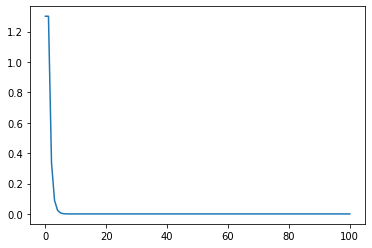

In [117]:
plt.plot(ys)

In [118]:
ys

[1.3010551224778428,
 1.3010551224778428,
 0.33631379140482504,
 0.08833055573199597,
 0.023344878683598427,
 0.005995760298727233,
 0.0013417833835896315,
 0.00018586562292986775,
 6.346765495175016e-06,
 8.418767741963373e-09,
 1.488739687083296e-14,
 3.469446951953614e-18,
 3.469446951953614e-18,
 3.469446951953614e-18,
 -3.469446951953614e-18,
 3.469446951953614e-18,
 -3.469446951953614e-18,
 3.469446951953614e-18,
 -3.469446951953614e-18,
 3.469446951953614e-18,
 -3.469446951953614e-18,
 3.469446951953614e-18,
 -3.469446951953614e-18,
 3.469446951953614e-18,
 -3.469446951953614e-18,
 3.469446951953614e-18,
 -3.469446951953614e-18,
 3.469446951953614e-18,
 -3.469446951953614e-18,
 3.469446951953614e-18,
 -3.469446951953614e-18,
 3.469446951953614e-18,
 -3.469446951953614e-18,
 3.469446951953614e-18,
 -3.469446951953614e-18,
 3.469446951953614e-18,
 -3.469446951953614e-18,
 3.469446951953614e-18,
 -3.469446951953614e-18,
 3.469446951953614e-18,
 -3.469446951953614e-18,
 3.4694469519

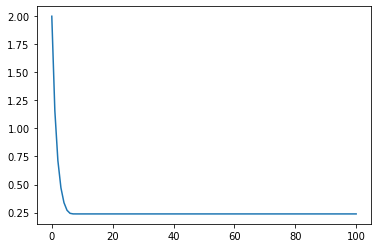

In [119]:
plt.plot(Ds)

In [120]:
Ds

[2,
 1.1592275452602552,
 0.7135103865556038,
 0.47114759291433683,
 0.33865130803695326,
 0.2705977176207918,
 0.24355552812944828,
 0.23840074167118944,
 0.23821185932414338,
 0.23821160811178332,
 0.2382116081113391,
 0.23821160811133898,
 0.23821160811133887,
 0.23821160811133876,
 0.23821160811133887,
 0.23821160811133876,
 0.23821160811133887,
 0.23821160811133876,
 0.23821160811133887,
 0.23821160811133876,
 0.23821160811133887,
 0.23821160811133876,
 0.23821160811133887,
 0.23821160811133876,
 0.23821160811133887,
 0.23821160811133876,
 0.23821160811133887,
 0.23821160811133876,
 0.23821160811133887,
 0.23821160811133876,
 0.23821160811133887,
 0.23821160811133876,
 0.23821160811133887,
 0.23821160811133876,
 0.23821160811133887,
 0.23821160811133876,
 0.23821160811133887,
 0.23821160811133876,
 0.23821160811133887,
 0.23821160811133876,
 0.23821160811133887,
 0.23821160811133876,
 0.23821160811133887,
 0.23821160811133876,
 0.23821160811133887,
 0.23821160811133876,
 0.2382116

In [59]:
equation(D)

1.1102230246251565e-16